In [7]:
import pandas as pd

# load the dataset
df = pd.read_csv("Netflix-Subscriptions.csv")
df.head()

,Time Period,Subscribers
0,1/4/13,34240000
1,1/7/13,35640000
2,1/10/2013,38010000
3,1/1/14,41430000
4,1/4/14,46130000


In [8]:
df['Time Period'] = pd.to_datetime(df['Time Period'],format='mixed',dayfirst=True,errors='coerce')
df = df.sort_values('Time Period')
df.set_index('Time Period', inplace=True)

df.head()

,Subscribers
Time Period,
2013-04-01,34240000
2013-07-01,35640000
2013-10-01,38010000
2014-01-01,41430000
2014-04-01,46130000


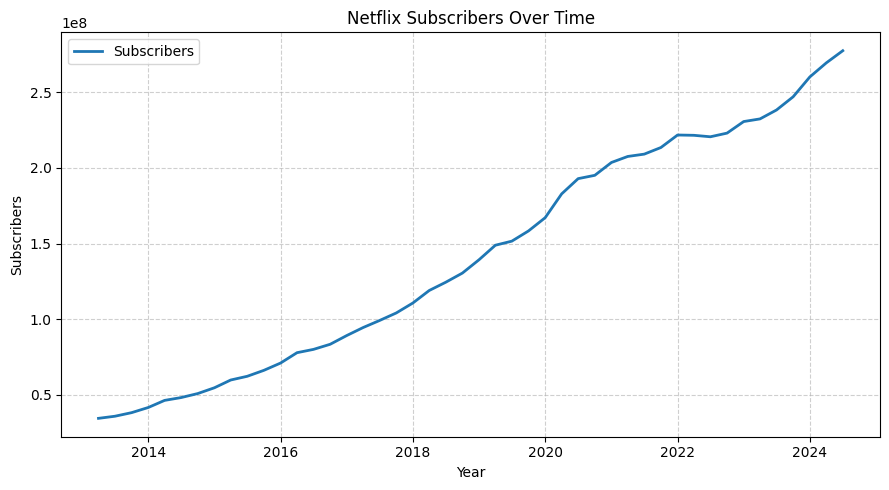

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    df.index,
    df["Subscribers"],
    linestyle='-',
    linewidth=2,
    label='Subscribers'
)

plt.title("Netflix Subscribers Over Time")
plt.xlabel("Year")
plt.ylabel("Subscribers")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna())

    print("ADF Test Results")
    print("-" * 30)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

    if result[1] <= 0.05:
        print("\n✅ Series is STATIONARY (reject H₀)")
    else:
        print("\n❌ Series is NOT stationary (fail to reject H₀)")


In [14]:
adf_test(df["Subscribers"])

ADF Test Results
------------------------------
ADF Statistic : 0.9991
p-value       : 0.9943
Critical Values:
  1%: -3.5886
  5%: -2.9299
  10%: -2.6032

❌ Series is NOT stationary (fail to reject H₀)


In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

def check_stationarity_matplotlib(timeseries, window=12):
    # rolling statistics
    roll_mean = timeseries.rolling(window=window).mean()
    roll_std = timeseries.rolling(window=window).std()

    plt.figure(figsize=(9, 5))

    plt.plot(timeseries, label='Original', color='blue')
    plt.plot(roll_mean, label='Rolling Mean', color='red', linestyle='--')
    plt.plot(roll_std, label='Rolling Std', color='green', linestyle=':')

    plt.title("Stationarity Check - Rolling Mean & Std")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.6)
    plt.tight_layout()
    plt.show()

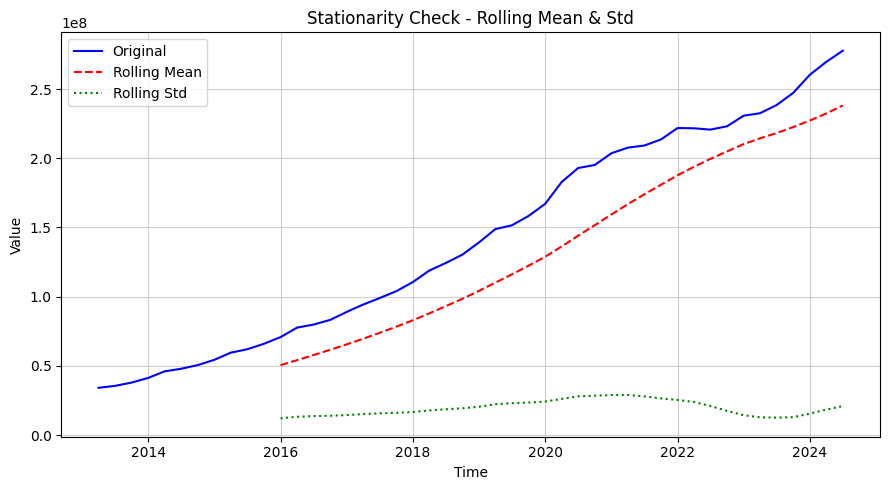

In [16]:
check_stationarity_matplotlib(df['Subscribers'])

In [21]:
df['Subscribers_diff'] = df['Subscribers'].diff().dropna()

In [22]:
df

,Subscribers,Subscribers_diff
Time Period,,
2013-04-01,34240000,NaN
2013-07-01,35640000,1400000.0
2013-10-01,38010000,2370000.0
2014-01-01,41430000,3420000.0
2014-04-01,46130000,4700000.0
2014-07-01,47990000,1860000.0
2014-10-01,50650000,2660000.0
2015-01-01,54480000,3830000.0
2015-04-01,59620000,5140000.0


In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

def plot_acf_pacf(
    ts,
    lags=50,
    pacf_method='ywm',
    figsize=(16, 4),
    dpi=120,
    title_suffix=""
):

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

    # ACF plot
    plot_acf(ts.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF (Autocorrelation) {title_suffix}")

    # PACF plot
    plot_pacf(ts.dropna(), lags=lags, ax=axes[1], method=pacf_method)
    axes[1].set_title(f"PACF (Partial Autocorrelation) {title_suffix}")

    plt.tight_layout()
    plt.show()

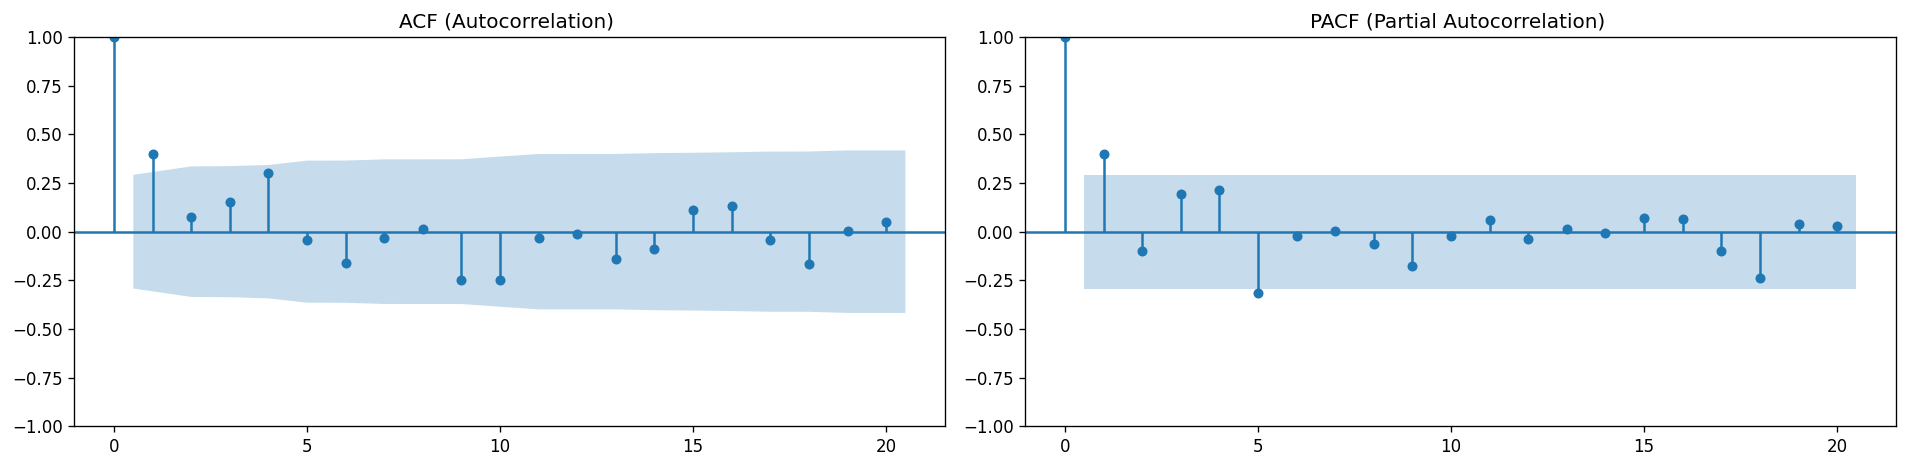

In [25]:
plot_acf_pacf(df['Subscribers_diff'], lags=20)

In [26]:
from statsmodels.tsa.arima.model import ARIMA

# fit ARIMA model
model = ARIMA(df['Subscribers'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

C:\Users\ASUS\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            Subscribers   No. Observations:                   46
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -741.278
Date:                Sun, 14 Dec 2025   AIC                           1488.556
Time:                        14:44:49   BIC                           1493.976
Sample:                    04-01-2013   HQIC                          1490.576
                         - 07-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.003    373.038      0.000       0.995       1.005
ma.L1         -0.9976      0.204     -4.882      0.000      -1.398      -0.597
sigma2      1.243e+13    1.6e-14   7.77e+26      0.0

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_forecast(df, forecast, steps=12, freq='Q'):
    future_dates = pd.date_range(start=df.index[-1],periods=steps + 1,freq=freq)[1:]

    plt.figure(figsize=(9, 5))
    # Actual data
    plt.plot(df.index,df['Subscribers'],
        label='Actual',
        color='blue',
        linewidth=2
    )
    # Forecast
    plt.plot(future_dates,forecast,
        label='Forecast',
        color='red',
        linestyle='--',
        linewidth=2
    )

    plt.title("Netflix Subscribers Forecast")
    plt.xlabel("Time")
    plt.ylabel("Subscribers")
    plt.legend()
    plt.grid(alpha=0.6)
    plt.tight_layout()
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3360\2363243257.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df.index[-1],periods=steps + 1,freq=freq)[1:]


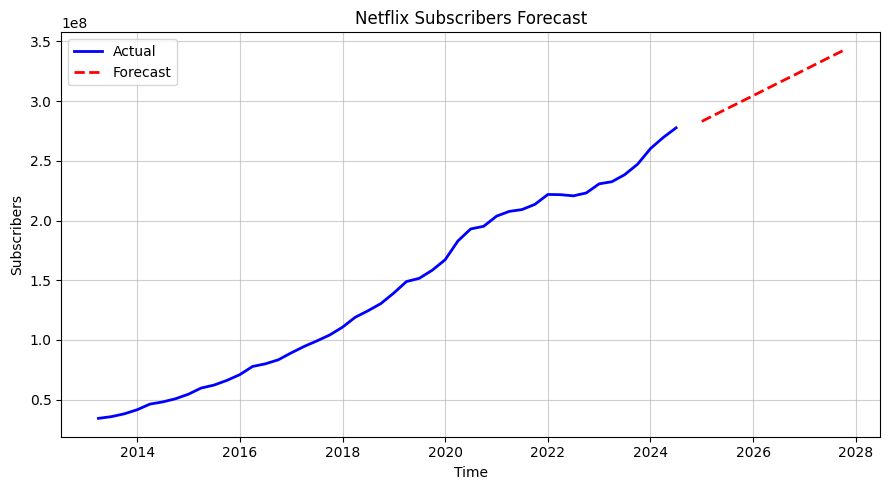

In [29]:
forecast = model_fit.forecast(steps=12)
plot_forecast(df, forecast, steps=12, freq='Q')